# Unit 2 — companion notebook
Code for the worked examples in the [Unit 2 notes](https://elevien.github.io/math50_sandbox/unit2/).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

rng = np.random.default_rng(0)

### Example: expectation of a discrete random variable

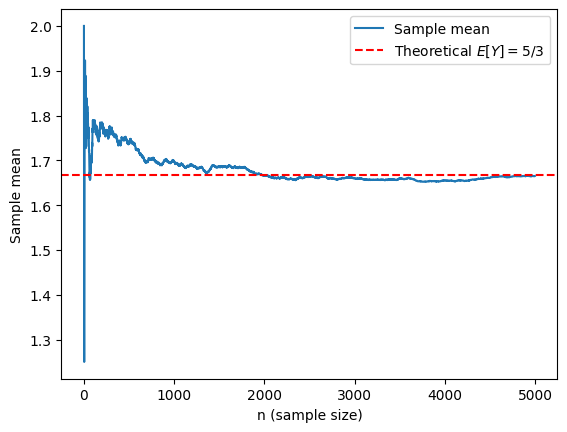

In [2]:
values = [1, 2, 3]
probs = [1/2, 1/3, 1/6]

Nmax = 5000
samples = rng.choice(values, size=Nmax, p=probs)
df = pd.DataFrame({"Y": samples})

sample_means = df["Y"].expanding().mean()

plt.plot(sample_means, label="Sample mean")
plt.axhline(5/3, color="red", linestyle="--", label="Theoretical $E[Y]=5/3$")
plt.xlabel("n (sample size)")
plt.ylabel("Sample mean")
plt.legend()
plt.show()

### Example: mean and variance of a Bernoulli random variable

In [3]:
q = 0.35
flips = rng.binomial(1, q, size=500_000)
print("E[Y] ~", flips.mean(), " (q =", q, ")")
print("var(Y) ~", flips.var(), " (q(1-q) =", q * (1 - q), ")")

E[Y] ~ 0.350872  (q = 0.35 )
var(Y) ~ 0.22776083961600005  (q(1-q) = 0.22749999999999998 )


### Example: computing a conditional expectation

In [4]:
P = {(0, 0): 1/2, (0, 1): 1/8, (1, 0): 1/8, (1, 1): 1/4}
P_B1 = P[(0, 1)] + P[(1, 1)]
E_YA_given_YB1 = P[(1, 1)] / P_B1  # Y_A is Bernoulli, so E[Y_A|.] = P(Y_A=1|.)
print("E[Y_A | Y_B=1] =", E_YA_given_YB1)

E[Y_A | Y_B=1] = 0.6666666666666666


### Example: conditional expectation from data (KidIQ)

In [5]:
url = (
    "https://raw.githubusercontent.com/"
    "avehtari/ROS-Examples/"
    "master/KidIQ/data/kidiq.csv"
)
df = pd.read_csv(url)
print(df[["kid_score", "mom_hs"]].head())

overall = df["kid_score"].mean()
by_mom_hs = df.groupby("mom_hs")["kid_score"].mean()

print("E[Y] estimated from all rows:")
print(overall)

print("E[Y | X=x] estimated within each group:")
print(by_mom_hs)

   kid_score  mom_hs
0         65       1
1         98       1
2         85       1
3         83       1
4        115       1
E[Y] estimated from all rows:
86.79723502304148
E[Y | X=x] estimated within each group:
mom_hs
0    77.548387
1    89.319648
Name: kid_score, dtype: float64


### Example: calculating conditional expectations with the tower property

In [ ]:
N = 100_000
X = rng.choice([0, 1], size=N, p=[0.6, 0.4])
Y = np.empty(N)
Y[X == 0] = rng.normal(loc=78, scale=8, size=np.sum(X == 0))
Y[X == 1] = rng.normal(loc=86, scale=8, size=np.sum(X == 1))
df = pd.DataFrame({"X": X, "Y": Y})

EY_given_X_hat = df.groupby("X")["Y"].mean().sort_index()
pX_hat = df["X"].value_counts(normalize=True).sort_index()
EEY_given_X_hat = (EY_given_X_hat * pX_hat).sum()

print(f"Theoretical E[Y]    = 81.200000")
print(f"Estimated E[Y]      = {df['Y'].mean():.6f}")
print(f"Estimated E[E[Y|X]] = {EEY_given_X_hat:.6f}")

### Example: expectation of a sum (Binomial mean and variance)

In [7]:
N, q = 20, 0.3
Y = rng.binomial(N, q, size=500_000)
print("E[Y] ~", Y.mean(), " (Nq =", N * q, ")")
print("var(Y) ~", Y.var(), " (Nq(1-q) =", N * q * (1 - q), ")")

E[Y] ~ 6.001138  (Nq = 6.0 )
var(Y) ~ 4.197464704956  (Nq(1-q) = 4.199999999999999 )


### Example: election modeling

In [8]:
q = 0.51
N = 1000
delta = 0.01
trials = 200_000

M_samples = rng.binomial(n=N, p=q, size=trials)
q_hat = M_samples / N
prob_est = np.mean(np.abs(q_hat - q) > delta)

print(f"Monte Carlo estimate P(|q_hat - {q}| > {delta}) = {prob_est:.6f}")

Monte Carlo estimate P(|q_hat - 0.51| > 0.01) = 0.548795


### Example: calculating Normal probabilities

In [ ]:
mu, sigma = 5, 2  # Normal(5, 4)
print("P(Y>7) exact:", 1 - norm.cdf(7, mu, sigma), " (bell curve shape: ~0.16)")
p = (norm.cdf(7, mu, sigma) - norm.cdf(3, mu, sigma)) / norm.cdf(7, mu, sigma)
print("P(Y>3 | Y<7) exact:", p, " (bell curve shape: ~0.81)")

### Example: binary predictor — the difference of means

In [10]:
def generate_data(beta0, beta1, sigma, n_samples):
    x = rng.choice([0, 1], n_samples)
    y = beta0 + beta1 * x + rng.normal(0, sigma, n_samples)
    return pd.DataFrame({"x": x, "y": y})

def beta1_hat(df):
    return df[df["x"] == 1]["y"].mean() - df[df["x"] == 0]["y"].mean()

df = generate_data(beta0=2, beta1=3, sigma=1, n_samples=5000)
print("beta1_hat =", beta1_hat(df), " (true beta1 = 3)")

beta1_hat = 3.054182014081044  (true beta1 = 3)


### Example: linear regression with a Normal predictor

In [11]:
mu_x, sigma_x, beta0, beta1, sigma = 1.0, 2.0, 0.5, 1.5, 1.0
X = rng.normal(mu_x, sigma_x, size=1_000_000)
Y = beta0 + beta1 * X + rng.normal(0, sigma, size=1_000_000)

predicted_EXY = beta1 * sigma_x**2 + beta1 * mu_x**2 + beta0 * mu_x
print("E[XY] ~", np.mean(X * Y), " predicted:", predicted_EXY)
print("E[X]E[Y] ~", X.mean() * Y.mean())

E[XY] ~ 7.993743435328224  predicted: 8.0
E[X]E[Y] ~ 1.9950503807833115
